# Dynamical Systems Tutorial Figures

This notebook contains the complete figure generation script for the Dynamical Systems tutorial. It generates all figures needed for the LaTeX presentation using Python, NumPy, Matplotlib, and SciPy.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

## 1. Lotka-Volterra Competition Model

This section generates the phase portrait for the Lotka-Volterra competition model between rabbits and sheep. It includes vector fields, trajectories from different initial conditions, nullclines, and fixed points.

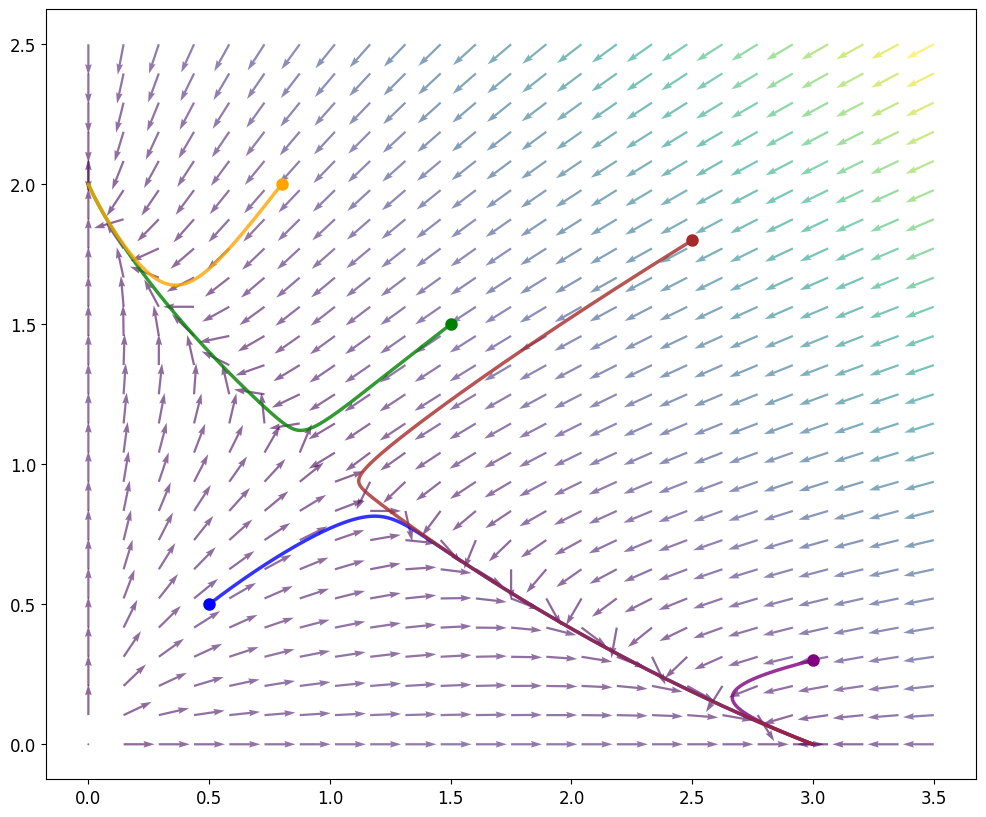

In [14]:
def lv_competition(state, t):
    x, y = state
    dxdt = x * (3 - x - 2 * y)
    dydt = y * (2 - x - y)
    return [dxdt, dydt]
# Phase portrait
x_range = np.linspace(0, 3.5, 25)
y_range = np.linspace(0, 2.5, 25)
X, Y = np.meshgrid(x_range, y_range)
U, V = np.zeros(X.shape), np.zeros(Y.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        U[i, j], V[i, j] = lv_competition([X[i, j], Y[i, j]], 0)
# Normalize for better visualization
M = np.sqrt(U**2 + V**2)
M[M == 0] = 1
U_norm, V_norm = U/M, V/M
plt.figure(figsize=(12, 10))
plt.quiver(X, Y, U_norm, V_norm, M, alpha=0.6, cmap='viridis', scale=30)
# Trajectories
t = np.linspace(0, 25, 2000)
initial_conditions = [[0.5, 0.5], [1.5, 1.5], [0.8, 2.0], [3.0, 0.3], [2.5, 1.8]]
colors = ['blue', 'green', 'orange', 'purple', 'brown']
for ic, color in zip(initial_conditions, colors):
    sol = odeint(lv_competition, ic, t)
    plt.plot(sol[:, 0], sol[:, 1], color=color, linewidth=2.5, alpha=0.8)
    plt.plot(sol[0, 0], sol[0, 1], 'o', color=color, markersize=8)

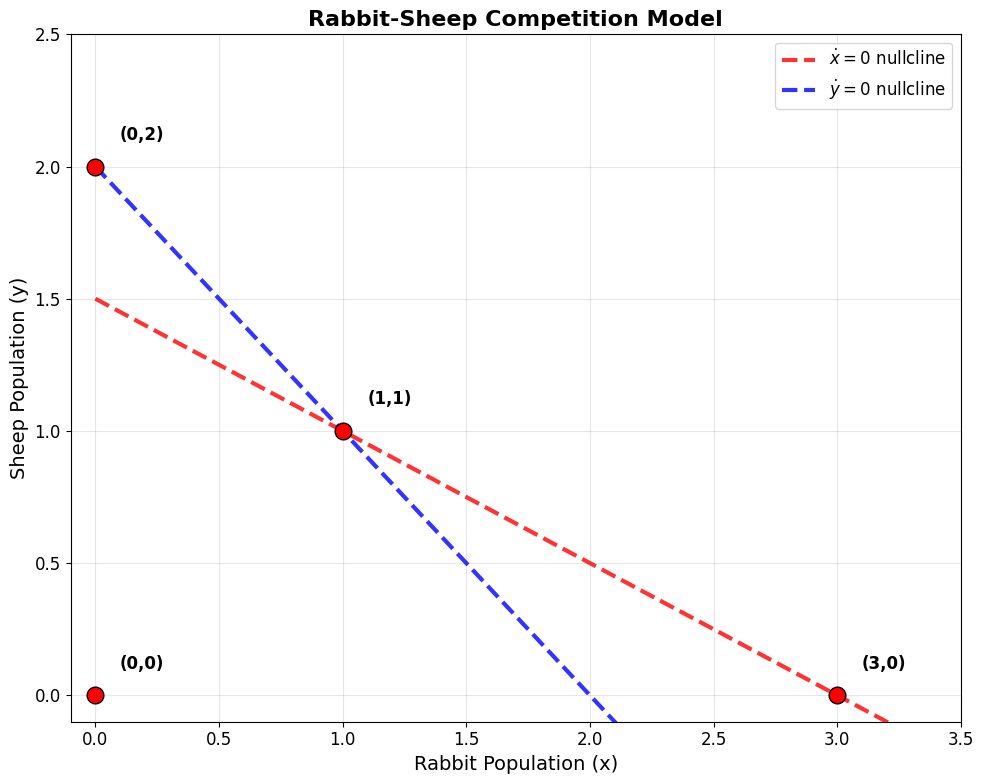

In [ ]:
# Nullclines
x_vals = np.linspace(0, 3.5, 100)
plt.plot(x_vals, (3 - x_vals)/2, 'r--', linewidth=3, alpha=0.8, label=r'$\dot{x}=0$ nullcline')
plt.plot(x_vals, 2 - x_vals, 'b--', linewidth=3, alpha=0.8, label=r'$\dot{y}=0$ nullcline')
fixed_points = [[0,0], [3,0], [0,2], [1,1]]
labels = ['(0,0)', '(3,0)', '(0,2)', '(1,1)']
for fp, label in zip(fixed_points, labels):
    plt.plot(fp[0], fp[1], 'ko', markersize=12, markerfacecolor='red')
    plt.text(fp[0]+0.1, fp[1]+0.1, label, fontsize=12, fontweight='bold')
plt.title('Rabbit-Sheep Competition Model', fontsize=16, fontweight='bold')
plt.xlabel('Rabbit Population (x)', fontsize=14)
plt.ylabel('Sheep Population (y)', fontsize=14)
plt.xlim(-0.1, 3.5)
plt.ylim(-0.1, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 2. Predator-Prey Time Series

This section simulates and plots the time series of predator-prey populations using the Lotka-Volterra equations, showing the characteristic oscillatory behavior.

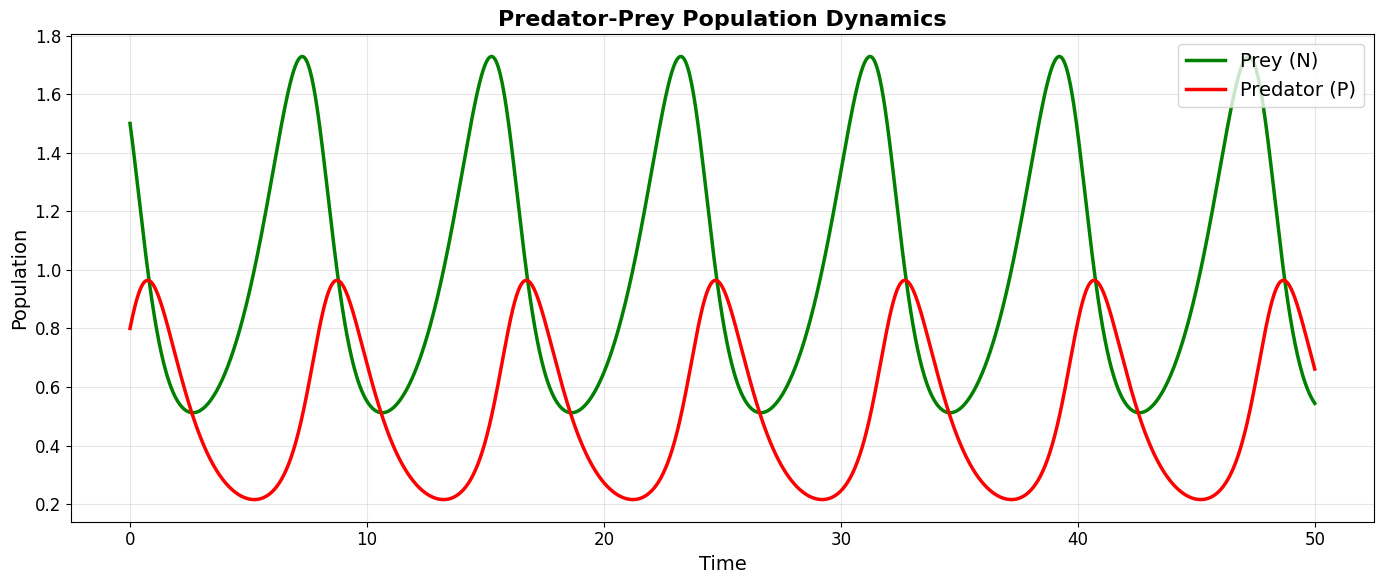

In [16]:
def lv_predator_prey(state, t, a=2/3, b=4/3, c=1, d=1):
    N, P = state
    dNdt = N * (a - b * P)
    dPdt = P * (c * N - d)
    return [dNdt, dPdt]

t_pp = np.linspace(0, 50, 2000)
ic_pp = [1.5, 0.8]
sol_pp = odeint(lv_predator_prey, ic_pp, t_pp)

plt.figure(figsize=(14, 6))
plt.plot(t_pp, sol_pp[:, 0], 'g-', linewidth=2.5, label='Prey (N)')
plt.plot(t_pp, sol_pp[:, 1], 'r-', linewidth=2.5, label='Predator (P)')
plt.title('Predator-Prey Population Dynamics', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Population', fontsize=14)
plt.legend(fontsize=14, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 3. Predator-Prey Phase Portrait

This section creates a phase space plot showing closed orbits for the predator-prey system from different initial conditions.

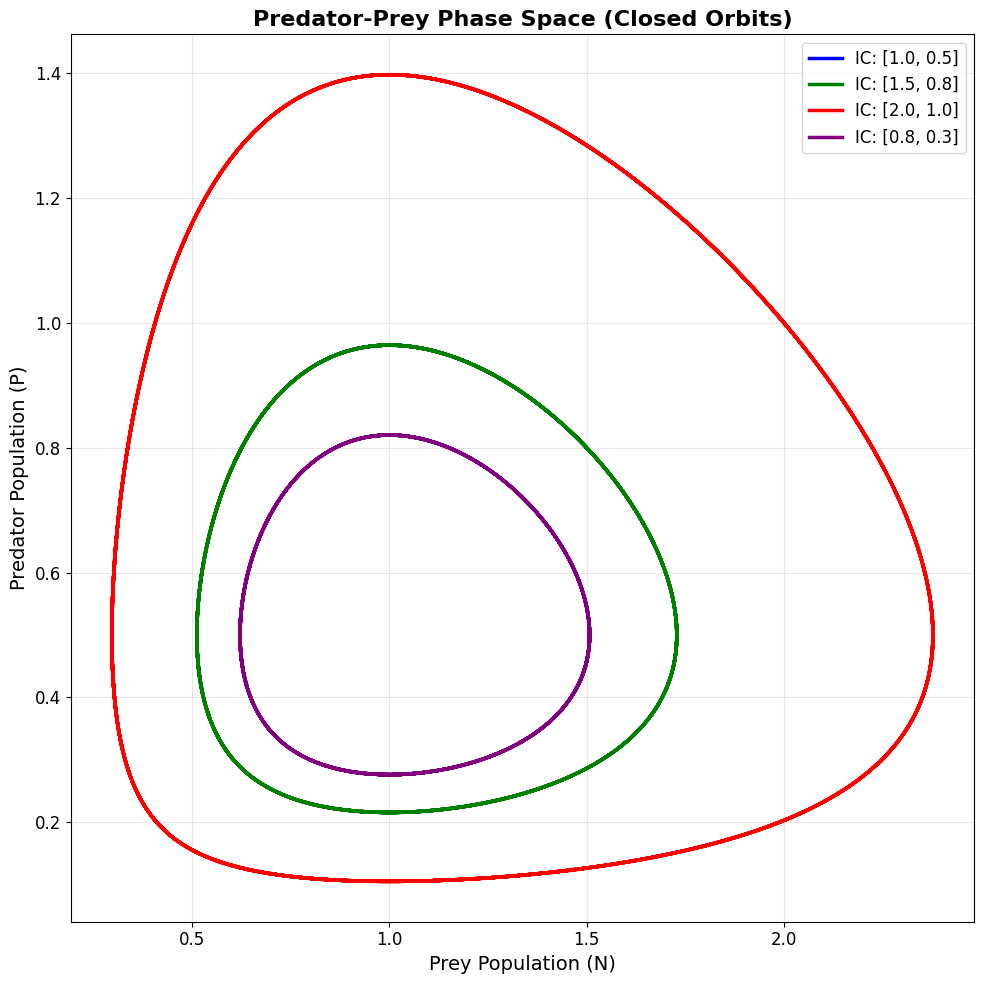

In [17]:
plt.figure(figsize=(10, 10))
ics_orbits = [[1.0, 0.5], [1.5, 0.8], [2.0, 1.0], [0.8, 0.3]]
colors_pp = ['blue', 'green', 'red', 'purple']

for ic, color in zip(ics_orbits, colors_pp):
    sol = odeint(lv_predator_prey, ic, t_pp)
    plt.plot(sol[:, 0], sol[:, 1], color=color, linewidth=2.5, label=f'IC: {ic}')

plt.title('Predator-Prey Phase Space (Closed Orbits)', fontsize=16, fontweight='bold')
plt.xlabel('Prey Population (N)', fontsize=14)
plt.ylabel('Predator Population (P)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 4. Historical Data (Simulated)

This section generates simulated historical data resembling the Hudson Bay Company fur records for snowshoe hares and Canada lynx, demonstrating the cyclic nature observed in real ecosystems.

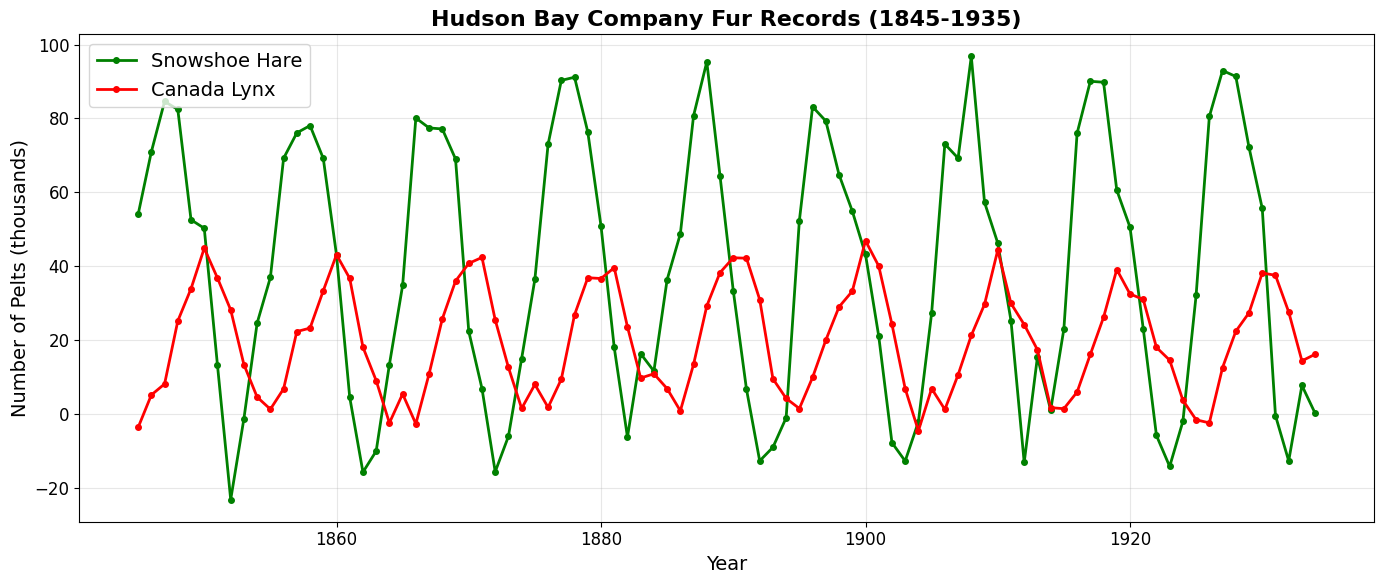

In [18]:
# Simulate historical-looking data
t_hist = np.arange(1845, 1935, 1)
# Real data approximation
hare_data = 40 + 50 * np.sin(2*np.pi*(t_hist-1845)/10) + 10*np.random.randn(len(t_hist))
lynx_data = 20 + 20 * np.sin(2*np.pi*(t_hist-1845-2.5)/10) + 5*np.random.randn(len(t_hist))

plt.figure(figsize=(14, 6))
plt.plot(t_hist, hare_data, 'go-', label='Snowshoe Hare', linewidth=2, markersize=4)
plt.plot(t_hist, lynx_data, 'ro-', label='Canada Lynx', linewidth=2, markersize=4)
plt.title('Hudson Bay Company Fur Records (1845-1935)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Pelts (thousands)', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 5. Lorenz Attractor

This section generates the famous Lorenz attractor, a chaotic system that exhibits sensitive dependence on initial conditions. The 3D trajectory shows the butterfly-shaped strange attractor.

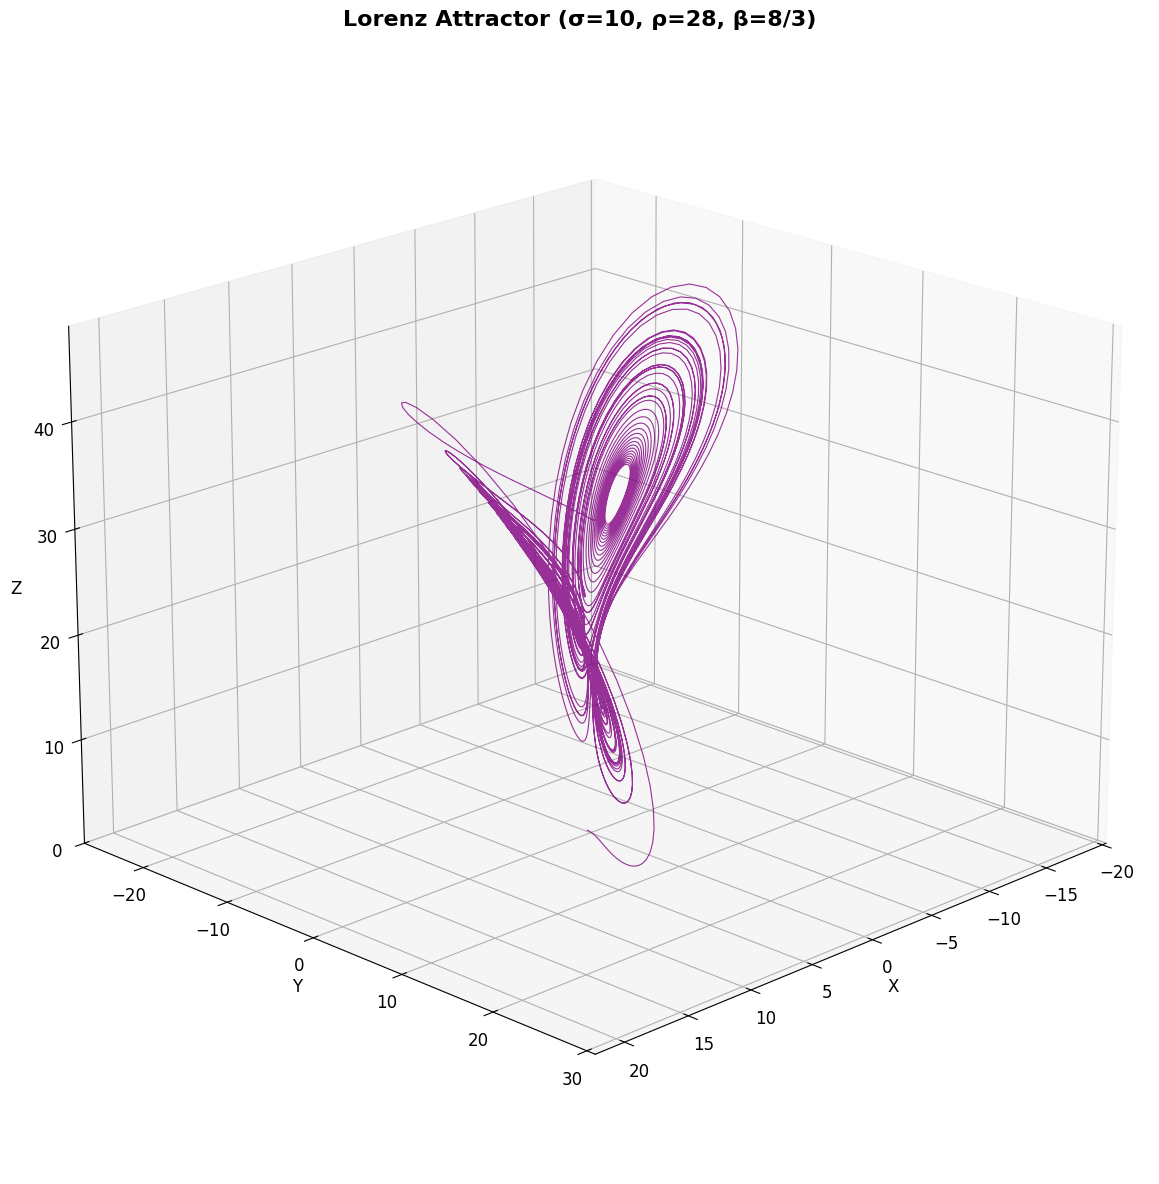

In [19]:
def lorenz_system(state, t, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

t_lorenz = np.linspace(0, 50, 5000)
initial_state = [1.0, 1.0, 1.0]
sol_lorenz = odeint(lorenz_system, initial_state, t_lorenz)

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_lorenz[:, 0], sol_lorenz[:, 1], sol_lorenz[:, 2], 
        lw=0.8, color='purple', alpha=0.8)
ax.set_title('Lorenz Attractor (σ=10, ρ=28, β=8/3)', fontsize=16, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_zlabel('Z', fontsize=12)
ax.view_init(elev=20, azim=45)
plt.tight_layout()

## 6. Lorenz Sensitivity to Initial Conditions

This section demonstrates the sensitive dependence on initial conditions in chaotic systems by plotting the distance between two trajectories starting from nearly identical initial conditions.

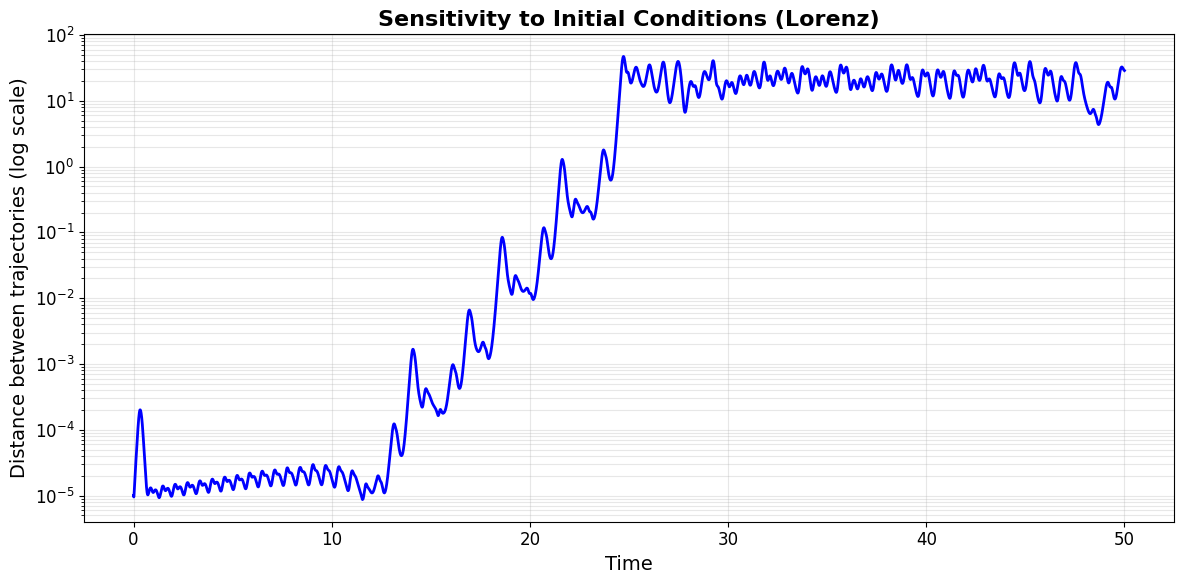

In [20]:
# Two nearby initial conditions
ic1 = [1.0, 1.0, 1.0]
ic2 = [1.0 + 1e-5, 1.0, 1.0]

sol1 = odeint(lorenz_system, ic1, t_lorenz)
sol2 = odeint(lorenz_system, ic2, t_lorenz)

# Compute distance
distance = np.sqrt((sol1[:,0]-sol2[:,0])**2 + 
                   (sol1[:,1]-sol2[:,1])**2 + 
                   (sol1[:,2]-sol2[:,2])**2)

plt.figure(figsize=(12, 6))
plt.semilogy(t_lorenz, distance, 'b-', linewidth=2)
plt.title('Sensitivity to Initial Conditions (Lorenz)', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Distance between trajectories (log scale)', fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()

## 7. Poincaré Section

This section creates a Poincaré section of the Lorenz attractor by sampling points where the trajectory crosses a specific plane, revealing the underlying structure of the chaotic attractor.

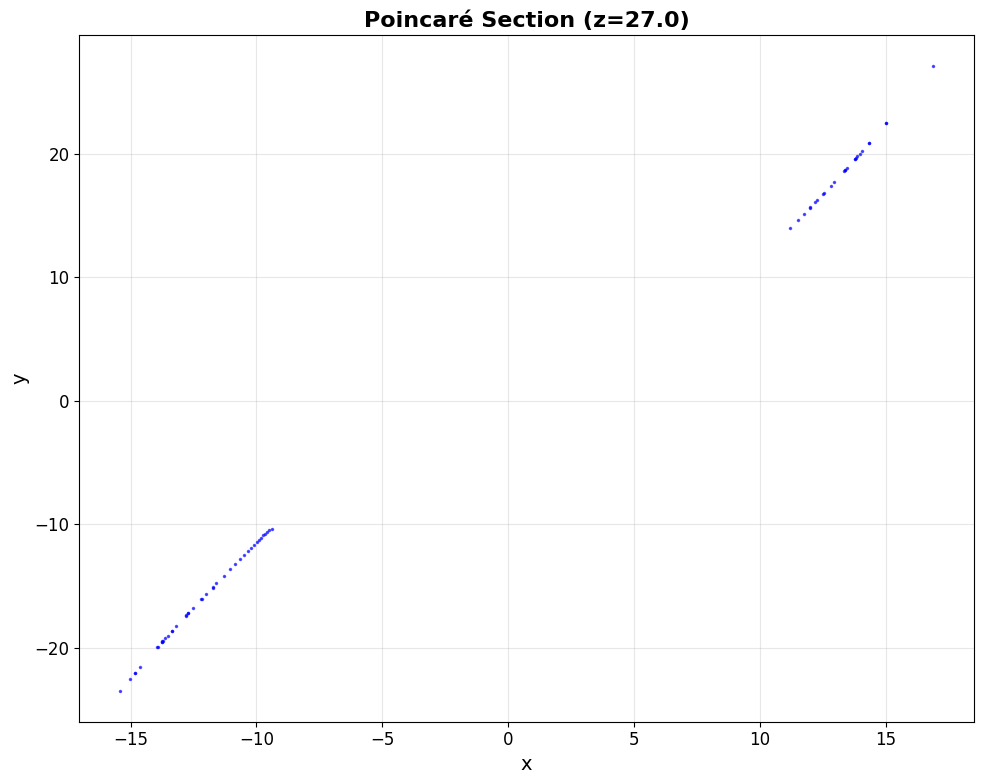

In [21]:
# Find intersections with z = rho - 1 plane
rho = 28
z_plane = rho - 1

# Find crossing indices (upward crossings)
crossings_x = []
crossings_y = []

for i in range(len(sol_lorenz)-1):
    if sol_lorenz[i, 2] < z_plane and sol_lorenz[i+1, 2] >= z_plane:
        # Linear interpolation
        alpha = (z_plane - sol_lorenz[i, 2]) / (sol_lorenz[i+1, 2] - sol_lorenz[i, 2])
        x_cross = sol_lorenz[i, 0] + alpha * (sol_lorenz[i+1, 0] - sol_lorenz[i, 0])
        y_cross = sol_lorenz[i, 1] + alpha * (sol_lorenz[i+1, 1] - sol_lorenz[i, 1])
        crossings_x.append(x_cross)
        crossings_y.append(y_cross)

plt.figure(figsize=(10, 8))
plt.plot(crossings_x, crossings_y, 'b.', markersize=3, alpha=0.6)
plt.title(f'Poincaré Section (z={z_plane:.1f})', fontsize=16, fontweight='bold')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 8. Hopf Bifurcation Diagrams

This section illustrates the difference between supercritical and subcritical Hopf bifurcations, showing how limit cycles emerge or disappear as a parameter is varied.

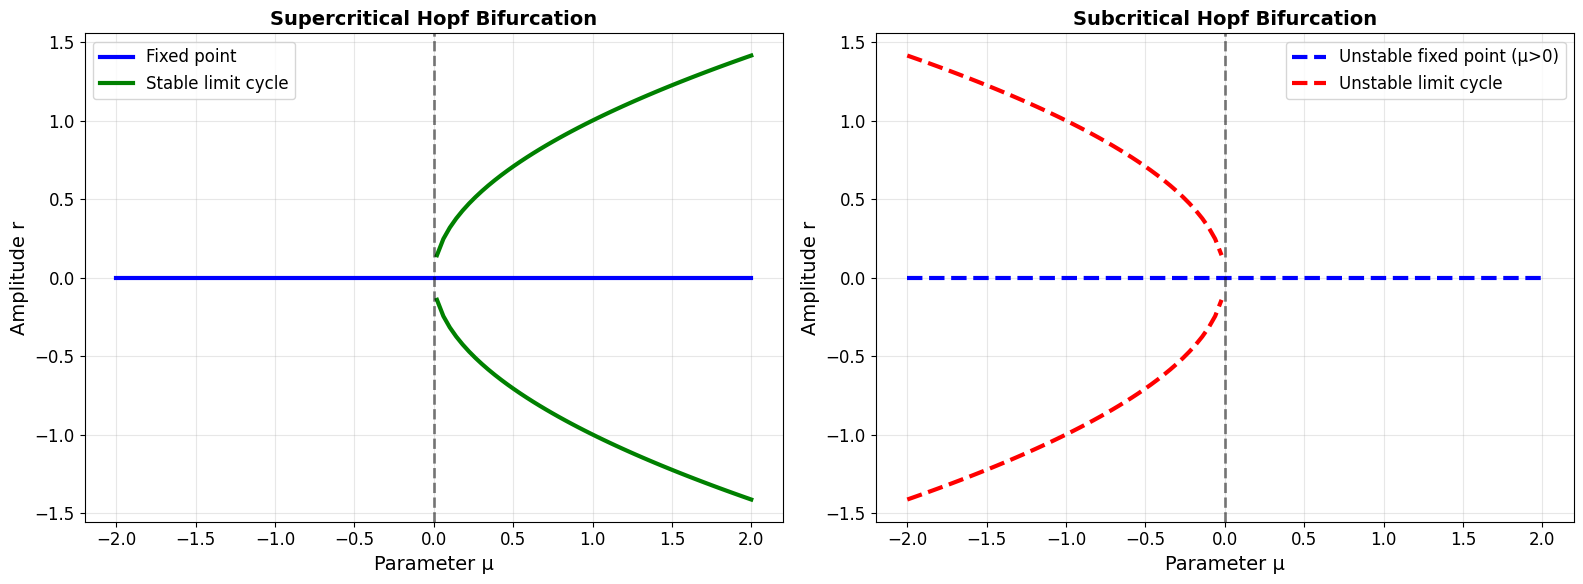

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Supercritical
mu_vals = np.linspace(-2, 2, 100)
axes[0].plot(mu_vals, 0*mu_vals, 'b-', linewidth=3, label='Fixed point')
mu_positive = mu_vals[mu_vals > 0]
r_stable = np.sqrt(mu_positive)
axes[0].plot(mu_positive, r_stable, 'g-', linewidth=3, label='Stable limit cycle')
axes[0].plot(mu_positive, -r_stable, 'g-', linewidth=3)
axes[0].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Parameter μ', fontsize=14)
axes[0].set_ylabel('Amplitude r', fontsize=14)
axes[0].set_title('Supercritical Hopf Bifurcation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Subcritical
axes[1].plot(mu_vals, 0*mu_vals, 'b--', linewidth=3, label='Unstable fixed point (μ>0)')
mu_negative = mu_vals[mu_vals < 0]
r_unstable = np.sqrt(-mu_negative)
axes[1].plot(mu_negative, r_unstable, 'r--', linewidth=3, label='Unstable limit cycle')
axes[1].plot(mu_negative, -r_unstable, 'r--', linewidth=3)
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Parameter μ', fontsize=14)
axes[1].set_ylabel('Amplitude r', fontsize=14)
axes[1].set_title('Subcritical Hopf Bifurcation', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

## 9. Hopf Supercritical Simulation

This section simulates the supercritical Hopf bifurcation, showing how trajectories spiral into a stable limit cycle when the parameter crosses the bifurcation point.

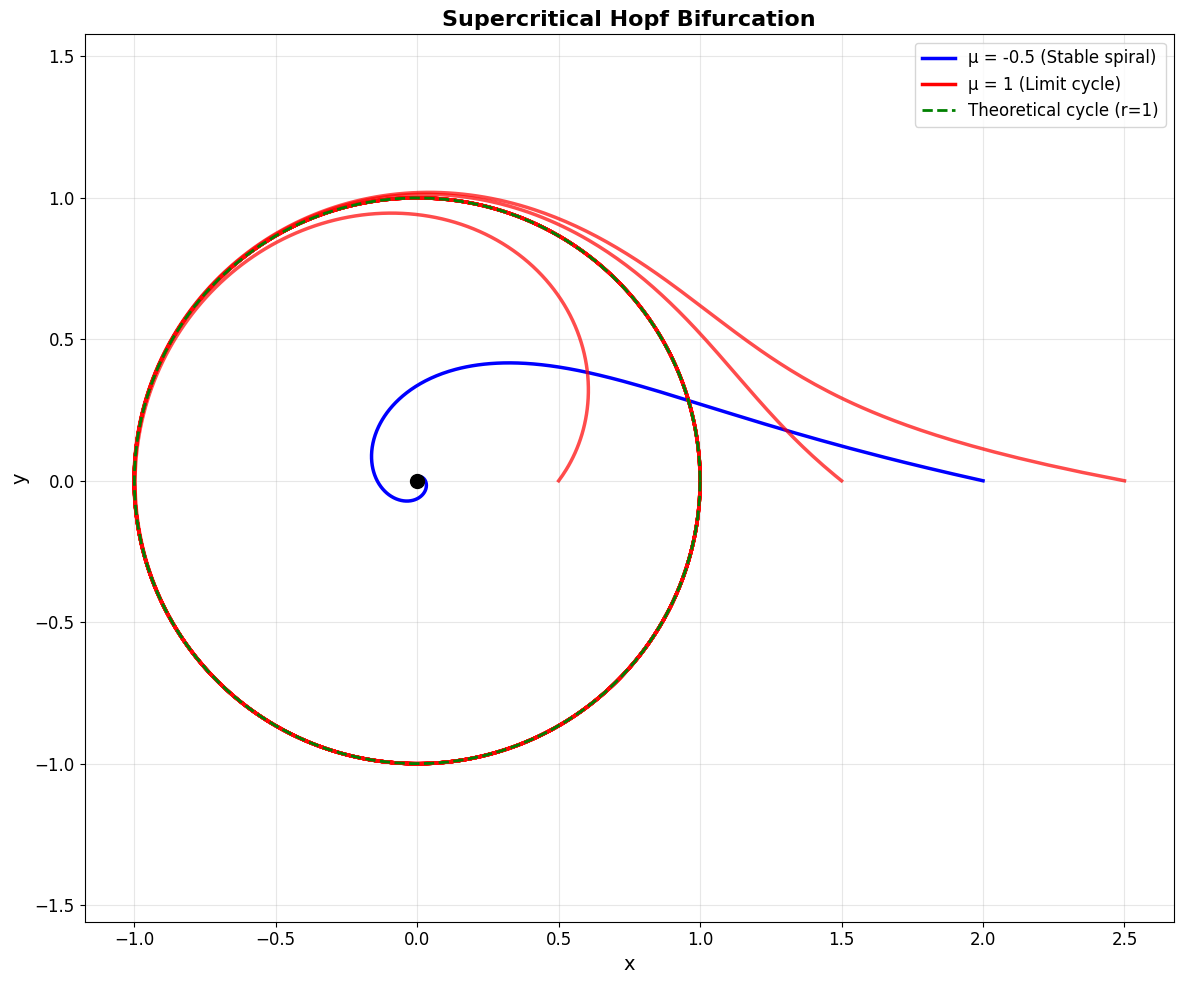

In [23]:
def hopf_super(state, t, mu, omega=1):
    x, y = state
    r2 = x**2 + y**2
    dxdt = mu * x - omega * y - x * r2
    dydt = omega * x + mu * y - y * r2
    return [dxdt, dydt]

t_hopf = np.linspace(0, 25, 2000)

plt.figure(figsize=(12, 10))

# mu < 0 (decay)
sol_neg = odeint(hopf_super, [2.0, 0], t_hopf, args=(-0.5, 1))
plt.plot(sol_neg[:,0], sol_neg[:,1], 'b-', linewidth=2.5, label='μ = -0.5 (Stable spiral)')

# mu > 0 (limit cycle)
for ic in [[0.5, 0], [1.5, 0], [2.5, 0]]:
    sol_pos = odeint(hopf_super, ic, t_hopf, args=(1, 1))
    plt.plot(sol_pos[:,0], sol_pos[:,1], 'r-', linewidth=2.5, alpha=0.7)

plt.plot([], [], 'r-', linewidth=2.5, label='μ = 1 (Limit cycle)')
plt.plot(0, 0, 'ko', markersize=10)

# Theoretical limit cycle
theta = np.linspace(0, 2*np.pi, 100)
r_theory = 1.0
plt.plot(r_theory*np.cos(theta), r_theory*np.sin(theta), 'g--', 
         linewidth=2, label='Theoretical cycle (r=1)')

plt.title('Supercritical Hopf Bifurcation', fontsize=16, fontweight='bold')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(fontsize=12)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 10. Hopf Subcritical Simulation

This section simulates the subcritical Hopf bifurcation, where an unstable limit cycle exists before the bifurcation, leading to hysteresis and potential jumps in behavior.

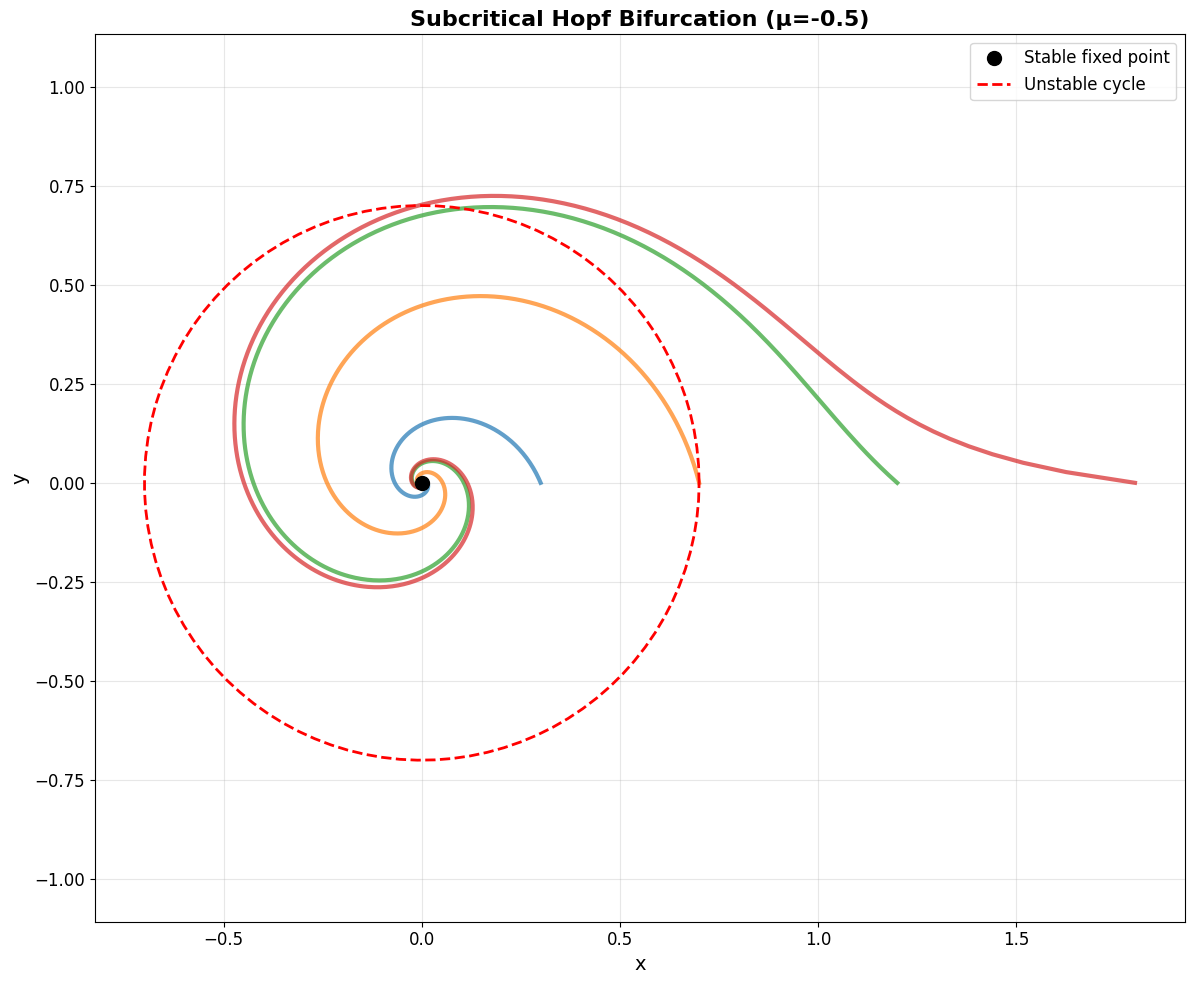

In [24]:
def hopf_sub(state, t, mu, omega=1):
    x, y = state
    r2 = x**2 + y**2
    # Subcritical with quintic stabilization
    dxdt = mu * x - omega * y + x * r2 - x * r2**2
    dydt = omega * x + mu * y + y * r2 - y * r2**2
    return [dxdt, dydt]

plt.figure(figsize=(12, 10))

# mu < 0 (stable fixed point with unstable cycle)
t_hopf_long = np.linspace(0, 50, 3000)
for ic in [[0.3, 0], [0.7, 0], [1.2, 0], [1.8, 0]]:
    sol_sub = odeint(hopf_sub, ic, t_hopf_long, args=(-0.5, 1))
    plt.plot(sol_sub[:,0], sol_sub[:,1], linewidth=3, alpha=0.7)

plt.plot(0, 0, 'ko', markersize=10, label='Stable fixed point')

# Unstable cycle (approximate)
theta = np.linspace(0, 2*np.pi, 100)
r_unstable = 0.7
plt.plot(r_unstable*np.cos(theta), r_unstable*np.sin(theta), 'r--', 
         linewidth=2, label='Unstable cycle')

plt.title('Subcritical Hopf Bifurcation (μ=-0.5)', fontsize=16, fontweight='bold')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend(fontsize=12)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## 11. Combined Hopf Visualization

This section provides a side-by-side comparison of supercritical and subcritical Hopf bifurcations, highlighting their different dynamical behaviors.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


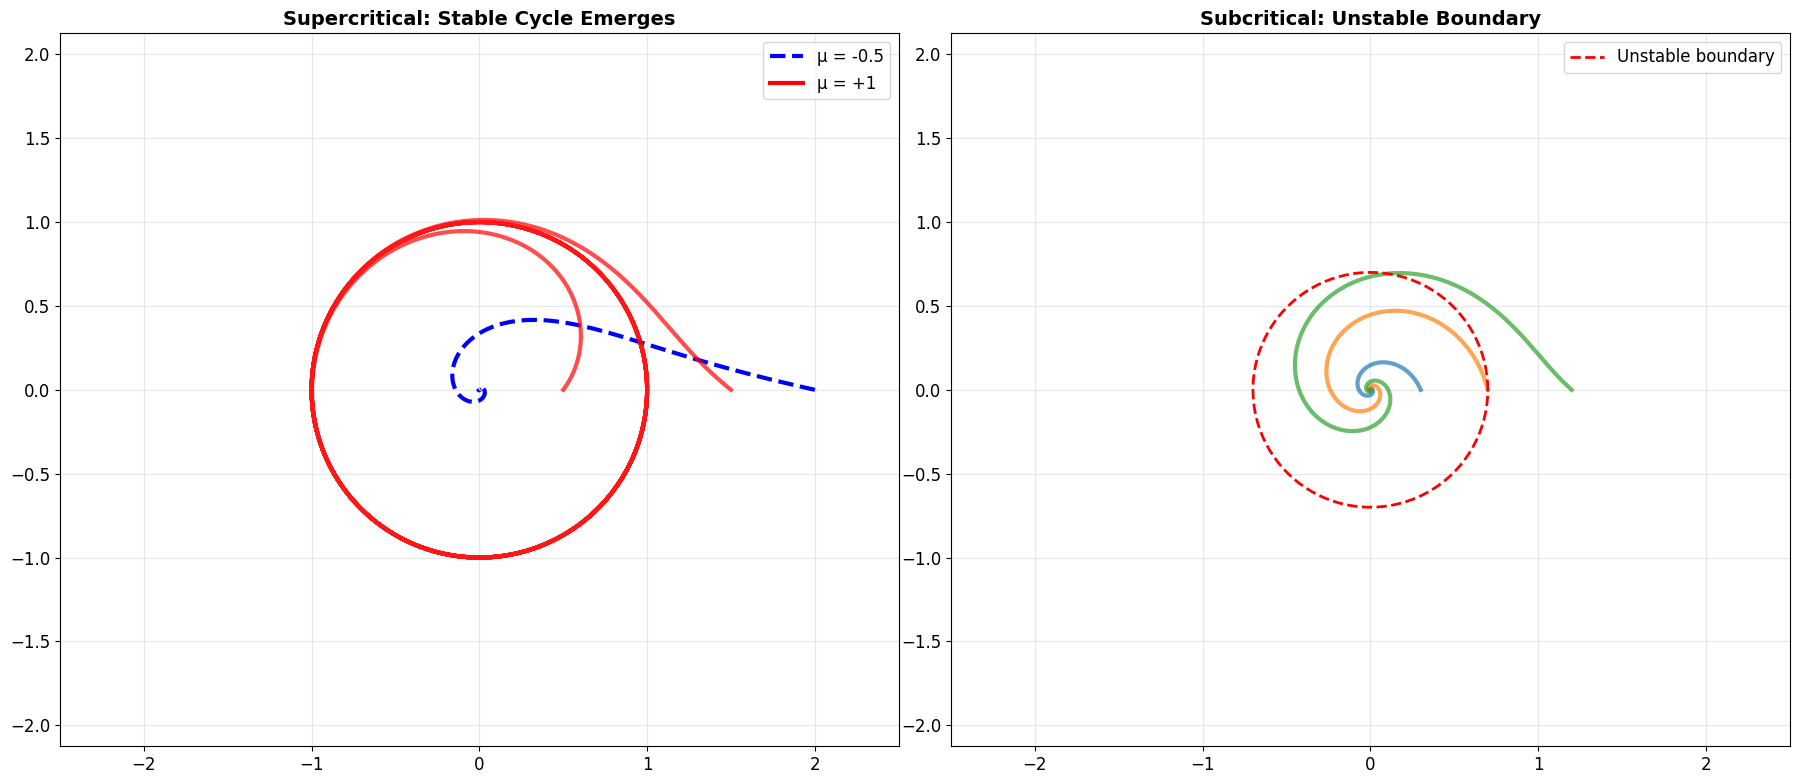

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Supercritical
sol_neg = odeint(hopf_super, [2.0, 0], t_hopf, args=(-0.5, 1))
axes[0].plot(sol_neg[:,0], sol_neg[:,1], 'b--', linewidth=3, label='μ = -0.5')

for ic in [[0.5, 0], [1.5, 0]]:
    sol_pos = odeint(hopf_super, ic, t_hopf, args=(1, 1))
    axes[0].plot(sol_pos[:,0], sol_pos[:,1], 'r-', linewidth=3, alpha=0.7)

axes[0].plot([], [], 'r-', linewidth=3, label='μ = +1')
axes[0].set_title('Supercritical: Stable Cycle Emerges', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(-2.5, 2.5)

# Right: Subcritical
for ic in [[0.3, 0], [0.7, 0], [1.2, 0]]:
    sol_sub = odeint(hopf_sub, ic, t_hopf_long, args=(-0.5, 1))
    axes[1].plot(sol_sub[:,0], sol_sub[:,1], linewidth=3, alpha=0.7)

theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(0.7*np.cos(theta), 0.7*np.sin(theta), 'r--', 
             linewidth=2, label='Unstable boundary')
axes[1].set_title('Subcritical: Unstable Boundary', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)

plt.tight_layout()